In [126]:
import matplotlib.pyplot as plt
import dask.array as da
from skimage.measure import label
import tifffile
import skimage as ski
import pandas as pd
import os
import numpy as np
from scipy import ndimage as ndi
import ops_process as ops
import segment_functions as fun
import importlib
importlib.reload(fun)


<module 'segment_functions' from '/Users/hannahbolen/Desktop/image_analysis/whole_slide/segment_functions.py'>

In [3]:
# read in image
root = "/Users/hannahbolen/Desktop/image_analysis/"
img_name = "o8p_day7_s12.ome.tif"
img_path = os.path.join(root, img_name)
img = da.from_array(tifffile.imread(img_path))
# assign channels
nuclei = img[0]
cy5 = img[1]
# constants -- display
ds = 10
H, W = nuclei.shape
y0 = H//2 - 5120 # underlying "tile" size of 512, make tile excerpt multiple of 512
x0 = W//2 - 5120
# make tile from center of image
nucleiTile = nuclei[y0:y0+5120, x0:x0+5120]
cy5Tile = cy5[y0:y0+5120, x0:x0+5120]
# make even smaller tile
nucleiZoom = nucleiTile[1000:3000, 2000:4000]
cy5Zoom = cy5Tile[1000:3000, 2000:4000]

In [160]:
# constants -- processing
umPerPx = 0.325
nucleiThreshold = 50
nucleiMin = 150/umPerPx**2
nucleiMax = 800/umPerPx**2
nucleiMean = 300/umPerPx**2
smooth=1.35
radius=300
# function to visualize
def compare_segmentation(base,**images):
    plt.figure(figsize = (18,18))
    plt.subplot(2, 3, 1)
    plt.axis('off')
    plt.imshow(base, cmap = "gray")
    plt.title("nuclei")
    for i, img in enumerate(images.keys(), start=2):
        plt.subplot(2,3,i)
        plt.title(img)
        plt.imshow(images[img])
        plt.axis('off')
        plt.tight_layout()
    plt.show()

In [26]:
mask = fun.binarize(nucleiZoom, 150, nucleiMin)

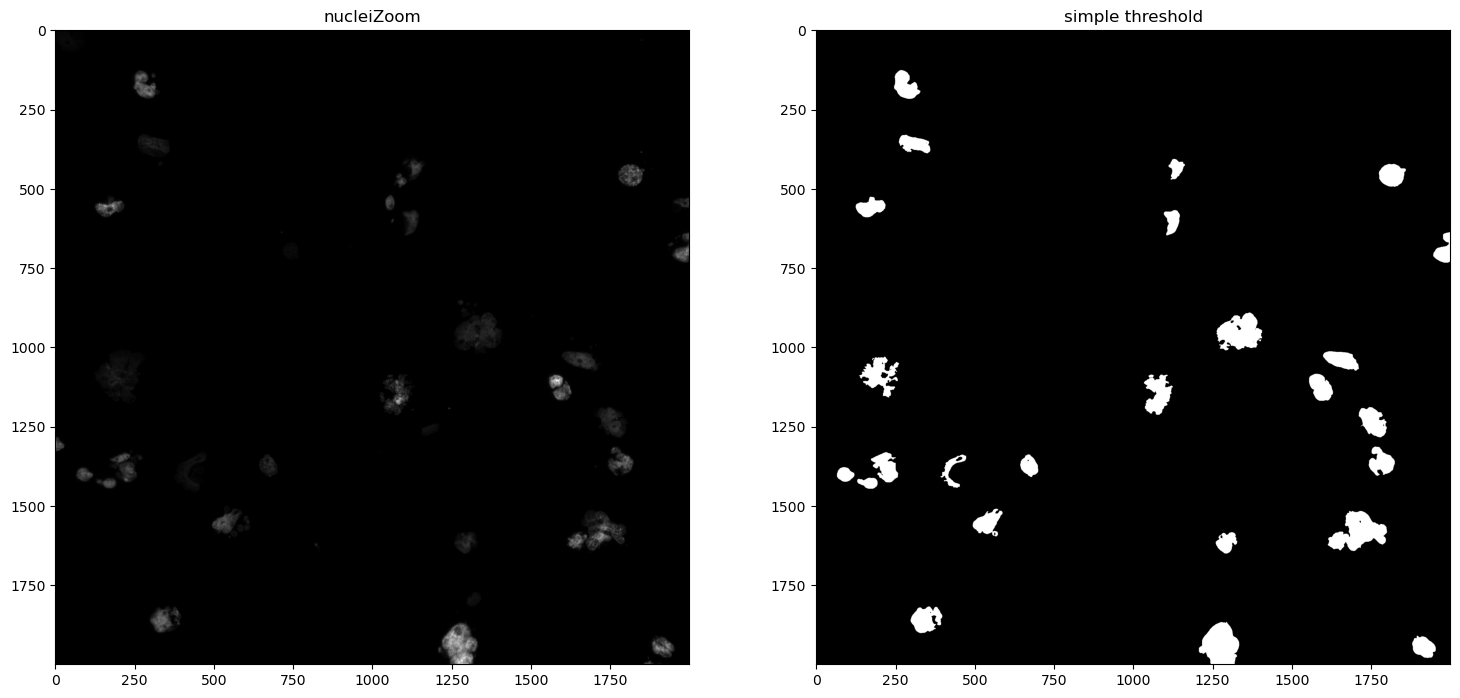

In [35]:
# alternative to binarize
threshold = 7
mask = ski.util.img_as_ubyte(ski.filters.gaussian(nucleiZoom, sigma = 1.5)) >= threshold
mask = ski.morphology.remove_small_objects(mask, min_size=nucleiMin)
compare_segmentation(mask, "simple threshold", clr = "gray")

In [137]:
importlib.reload(fun)

<module 'segment_functions' from '/Users/hannahbolen/Desktop/image_analysis/whole_slide/segment_functions.py'>

In [200]:
threshold = 7
mask = ski.util.img_as_ubyte(ski.filters.gaussian(nucleiTile, sigma = 1.8)) >= threshold
mask = ski.morphology.remove_small_objects(mask, min_size=nucleiMin)
labeled = ski.measure.label(mask)
labeled = fun.filter_by_region(labeled, threshold=lambda x: nucleiThreshold, intensity_image=nucleiTile) > 0
filled = ndi.binary_fill_holes(labeled)
difference = ski.measure.label(filled != labeled)
change = fun.filter_by_region(difference, score=lambda r: r.area < nucleiMin, threshold=0) > 0
labeled[change] = filled[change]
nuclei = fun.apply_watershed(labeled,smooth=3)
result = fun.filter_by_region(nuclei, score=lambda r: nucleiMin < r.area < 12000, threshold=5)
boundaries = ski.segmentation.mark_boundaries(ski.exposure.rescale_intensity(nucleiTile,in_range = (256, 12000)), result, mode="thick")

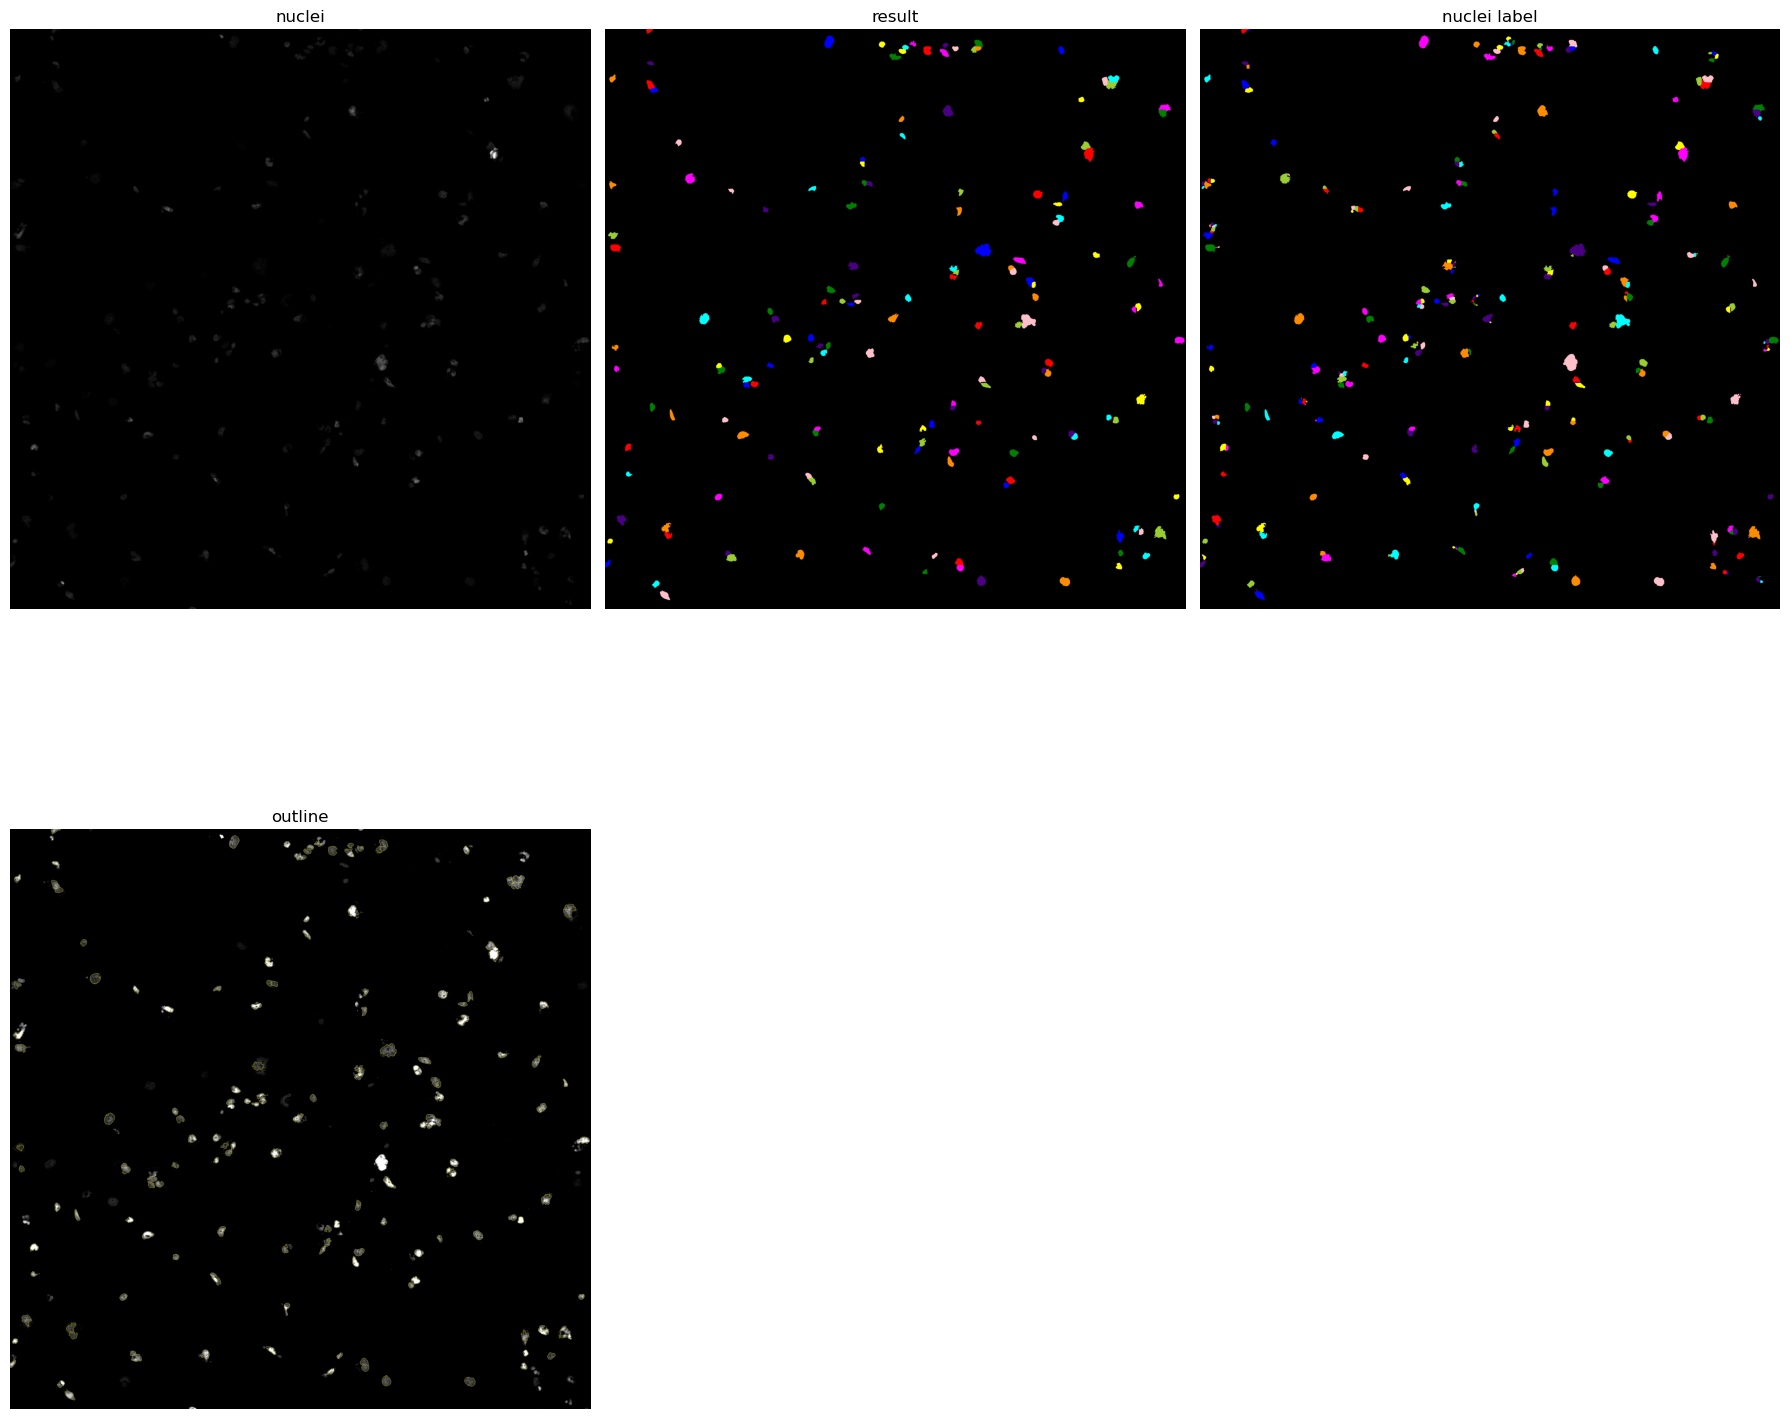

In [201]:
images = {"result":ski.color.label2rgb(result), "nuclei label":ski.color.label2rgb(nuclei), "outline":boundaries}
compare_segmentation(nucleiTile,**images)

In [193]:
props = pd.DataFrame(ski.measure.regionprops_table(nuclei, properties=['area']))
s = props.sort_values("area",ascending=False)
s.head()

,area
53,11910.0
13,11188.0
47,10638.0
52,4698.0
7,4651.0


area    11910.0
dtype: float64

In [95]:
ops.OPS_PROFILE = True
ops.OPS_PROFILE_VERBOSE = True
ops.ops_timing_reset()
kwargs = dict(threshold=lambda x: nucleiThreshold, 
            area_min=nucleiMin, area_max=nucleiMax,
            smooth=smooth, radius=radius)
findNuclei = ops.find_nuclei(nucleiZoom, **kwargs)

[ops_timer] binarize: 6.192s
[ops_timer] label: 0.007s
[ops_timer] filter_by_region_initial: 0.200s
[ops_timer] fill_holes: 0.049s
[ops_timer] label_hole_diff: 0.007s
[ops_timer] filter_by_region_holes: 0.040s
[ops_timer] apply_hole_fill: 0.002s
[ops_timer] watershed: 0.213s
[ops_timer] filter_by_region_final: 0.048s
